# PyTorch ANN Binary Classifier (GPU + Optuna + Global Threshold Calibration)
Optimized for Precision-heavy Metric (F0.5) with Singleton Handling.
Features are standardized, and architecture is dynamically tuned via Optuna.


### 1. Imports and Configuration


In [8]:
import os, gc, time, json, shutil
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import StandardScaler
import warnings

# Suppress all future and runtime warnings globally
warnings.filterwarnings('ignore')


try:
    import optuna
except ImportError:
    os.system("pip install -q optuna")
    import optuna

try:
    from tqdm.auto import tqdm
except ImportError:
    os.system("pip install -q tqdm")
    from tqdm.auto import tqdm

import joblib
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

DATA_PATH = Path('/kaggle/input/datasets/vinaysingh120221/training-data-01/training_features_full.csv')
OUTPUT_DIR = Path('/kaggle/working/ann_classifier')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RANDOM_STATE = 42
VALIDATION_FRACTION = 0.2
N_TRIALS = 15
USE_GPU = True
device = torch.device('cuda' if torch.cuda.is_available() and USE_GPU else 'cpu')
print(f"Using device: {device}")


Using device: cuda


### 2. Loading Data


In [9]:
print("[INFO] Loading data in chunks to save RAM...")
chunk_size = 1000000  # 1 million rows at a time
chunks = []

for chunk in pd.read_csv(DATA_PATH, dtype={"query_id": str, "candidate_id": str}, chunksize=chunk_size):
    chunk['label'] = chunk['label'].astype(np.int8)
    feature_cols = [c for c in chunk.columns if c not in ['query_id', 'candidate_id', 'label']]
    for c in feature_cols:
        chunk[c] = pd.to_numeric(chunk[c], errors='coerce').fillna(0.0).astype(np.float32)
    chunks.append(chunk)

df = pd.concat(chunks, ignore_index=True)
del chunks
gc.collect()

FEATURE_COLUMNS = feature_cols
print(f"Shape: {df.shape} | Features: {len(FEATURE_COLUMNS)}")
print(f"Total RAM usage of dataframe: {df.memory_usage(deep=True).sum() / 1e9:.2f} GB")


[INFO] Loading data in chunks to save RAM...
Shape: (1048575, 36) | Features: 33
Total RAM usage of dataframe: 0.27 GB


### 3. Query Partitioned Split & Feature Scaling
(Neural Networks require standardized inputs)


In [10]:
def query_partitioned_split(dataset_df, val_fraction=0.2, random_state=42):
    unique_queries = np.array(sorted(dataset_df["query_id"].unique()))
    rng = np.random.default_rng(random_state)
    rng.shuffle(unique_queries)
    val_size = max(1, int(len(unique_queries) * val_fraction))
    val_query_set = set(unique_queries[:val_size])
    
    train_df = dataset_df[~dataset_df["query_id"].isin(val_query_set)].copy()
    val_df = dataset_df[dataset_df["query_id"].isin(val_query_set)].copy()
    
    train_df = train_df.sort_values("query_id").reset_index(drop=True)
    val_df = val_df.sort_values("query_id").reset_index(drop=True)
    return train_df, val_df

train_df, val_df = query_partitioned_split(df, val_fraction=VALIDATION_FRACTION, random_state=RANDOM_STATE)

# For Neural Networks, feature scaling is mandatory
print("[INFO] Scaling Features with StandardScaler...")
scaler = StandardScaler()
X_train = scaler.fit_transform(train_df[FEATURE_COLUMNS])
X_val = scaler.transform(val_df[FEATURE_COLUMNS])
y_train = train_df["label"].to_numpy(dtype=np.float32)
y_val = val_df["label"].to_numpy(dtype=np.float32)

joblib.dump(scaler, OUTPUT_DIR / "ann_scaler.joblib")


[INFO] Scaling Features with StandardScaler...


['/kaggle/working/ann_classifier/ann_scaler.joblib']

### 4. Custom Metrics & Threshold Tuner


In [11]:
# Pre-compute Ground Truth Dicts for Evaluation
val_y_true_by_query = val_df[val_df['label'] == 1].groupby('query_id')['candidate_id'].apply(set).to_dict()
val_all_queries = set(val_df['query_id'].unique())

def macro_f05(y_true_by_query, pred_by_query, all_queries):
    scores = []
    # Using a fast list comprehension for the loop
    for qid in all_queries:
        true_set = y_true_by_query.get(qid, set())
        pred_set = pred_by_query.get(qid, set()) # Already a set now
        if not true_set:
            scores.append(1.0 if not pred_set else 0.0)
        else:
            tp = len(true_set & pred_set)
            precision = tp / len(pred_set) if pred_set else 0.0
            recall = tp / len(true_set)
            if precision == 0 and recall == 0:
                scores.append(0.0)
            else:
                scores.append((1.25 * precision * recall) / (0.25 * precision + recall))
    return np.mean(scores)

def exhaustive_threshold_search(val_preds_df, fast_mode=False):
    print("[INFO] Running Threshold Sweep...")
    
    best_f05 = -1
    best_config = {}
    
    from collections import defaultdict
    qids = val_preds_df['query_id'].values
    cids = val_preds_df['candidate_id'].values
    scores = val_preds_df['score'].values
    
    unique_scores = np.sort(val_preds_df['score'].unique())[::-1]
    pct_count = 20 if fast_mode else 100
    test_thresh = np.percentile(unique_scores, np.linspace(0, 100, pct_count))
    
    for t in tqdm(test_thresh, desc="Global Threshold Sweep", disable=fast_mode):
        mask = (scores >= t)
        
        pred_dict = defaultdict(set)
        for q, c in zip(qids[mask], cids[mask]):
            pred_dict[q].add(c)
            
        score = macro_f05(val_y_true_by_query, pred_dict, val_all_queries)
        if score > best_f05:
            best_f05 = score; best_config = {'threshold': t}
                
    return best_f05, best_config


### 5. PyTorch DataLoader & Model Setup


In [12]:
class PairwiseANN(nn.Module):
    def __init__(self, input_dim, hidden_layers, dropout_rate):
        super(PairwiseANN, self).__init__()
        layers = []
        prev_dim = input_dim
        for h_dim in hidden_layers:
            layers.append(nn.Linear(prev_dim, h_dim))
            layers.append(nn.BatchNorm1d(h_dim))
            layers.append(nn.ReLU())
            layers.append(nn.Dropout(dropout_rate))
            prev_dim = h_dim
        layers.append(nn.Linear(prev_dim, 1))
        self.network = nn.Sequential(*layers)
        
    def forward(self, x):
        return self.network(x).squeeze(1)

def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0
    for batch_x, batch_y in dataloader:
        batch_x, batch_y = batch_x.to(device), batch_y.to(device)
        optimizer.zero_grad()
        logits = model(batch_x)
        loss = criterion(logits, batch_y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    return total_loss / len(dataloader)

def predict_proba(model, dataloader, device):
    model.eval()
    all_probs = []
    with torch.no_grad():
        for batch_x, _ in dataloader:
            batch_x = batch_x.to(device)
            logits = model(batch_x)
            probs = torch.sigmoid(logits)
            all_probs.append(probs.cpu().numpy())
    return np.concatenate(all_probs)

train_dataset = TensorDataset(torch.tensor(X_train), torch.tensor(y_train))
val_dataset = TensorDataset(torch.tensor(X_val), torch.tensor(y_val))

# Using a large batch size since we have millions of rows
BATCH_SIZE = 4096
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=False)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)


### 6. Hyperparameter Tuning (Optuna)
Tuning depth, width, dropout, and learning rate.


In [13]:
print("[INFO] Tuning PyTorch ANN...")
def objective(trial):
    # Hyperparameters
    n_layers = trial.suggest_int('n_layers', 2, 4)
    hidden_layers = []
    for i in range(n_layers):
        hidden_layers.append(trial.suggest_categorical(f'n_units_l{i}', [64, 128, 256, 512]))
    
    dropout_rate = trial.suggest_float('dropout_rate', 0.1, 0.5)
    lr = trial.suggest_categorical('lr', [1e-3, 5e-4, 1e-4])
    weight_decay = trial.suggest_categorical('weight_decay', [1e-5, 1e-4, 0.0])
    
    model = PairwiseANN(input_dim=len(FEATURE_COLUMNS), hidden_layers=hidden_layers, dropout_rate=dropout_rate).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)
    criterion = nn.BCEWithLogitsLoss()
    
    epochs = 3
    for epoch in range(epochs):
        train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
        
    val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
    val_preds['score'] = predict_proba(model, val_loader, device)
    
    best_f05, _ = exhaustive_threshold_search(val_preds, fast_mode=True)
    return best_f05

study = optuna.create_study(direction="maximize")
study.optimize(objective, n_trials=N_TRIALS, show_progress_bar=True)
print(f"\n🏆 Best Macro F0.5: {study.best_value:.5f}")
print(f"🏆 Best Params: {study.best_params}")


[I 2026-09-29 01:13:02,262] A new study created in memory with name: no-name-2a57d20e-3358-49c5-bd1a-a1dd72361b60


[INFO] Tuning PyTorch ANN...


  0%|          | 0/15 [00:00<?, ?it/s]

[INFO] Running Threshold Sweep...
[I 2026-09-29 01:13:40,719] Trial 0 finished with value: 0.9426084098920469 and parameters: {'n_layers': 3, 'n_units_l0': 128, 'n_units_l1': 512, 'n_units_l2': 128, 'dropout_rate': 0.41152561880690197, 'lr': 0.001, 'weight_decay': 1e-05}. Best is trial 0 with value: 0.9426084098920469.
[INFO] Running Threshold Sweep...
[I 2026-09-29 01:14:13,839] Trial 1 finished with value: 0.915791717469107 and parameters: {'n_layers': 3, 'n_units_l0': 64, 'n_units_l1': 64, 'n_units_l2': 128, 'dropout_rate': 0.296722059588433, 'lr': 0.0001, 'weight_decay': 0.0001}. Best is trial 0 with value: 0.9426084098920469.
[INFO] Running Threshold Sweep...
[I 2026-09-29 01:14:48,837] Trial 2 finished with value: 0.9425694640452424 and parameters: {'n_layers': 3, 'n_units_l0': 512, 'n_units_l1': 512, 'n_units_l2': 128, 'dropout_rate': 0.3779041807284198, 'lr': 0.0005, 'weight_decay': 0.0}. Best is trial 0 with value: 0.9426084098920469.
[INFO] Running Threshold Sweep...
[I 2026-

### 7. Retrain Best Model & Extract Matches


In [14]:
# === RETRAIN BEST MODEL ===
best_params = study.best_params
n_layers = best_params['n_layers']
hidden_layers = [best_params[f'n_units_l{i}'] for i in range(n_layers)]

print("[INFO] Retraining final ANN model with best params on GPU...")
final_model = PairwiseANN(input_dim=len(FEATURE_COLUMNS), hidden_layers=hidden_layers, dropout_rate=best_params['dropout_rate']).to(device)
optimizer = optim.Adam(final_model.parameters(), lr=best_params['lr'], weight_decay=best_params['weight_decay'])
criterion = nn.BCEWithLogitsLoss()

EPOCHS = 10
best_val_f05 = -1
best_model_state = None
best_thresh_config = None

for epoch in range(EPOCHS):
    train_loss = train_epoch(final_model, train_loader, optimizer, criterion, device)
    val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
    val_preds['score'] = predict_proba(final_model, val_loader, device)
    val_f05, thresh_config = exhaustive_threshold_search(val_preds, fast_mode=True)
    print(f"Epoch {epoch+1}/{EPOCHS} | Train Loss: {train_loss:.4f} | Val F0.5: {val_f05:.4f}")
    
    if val_f05 > best_val_f05:
        best_val_f05 = val_f05
        best_model_state = final_model.state_dict().copy()
        best_thresh_config = thresh_config

final_model.load_state_dict(best_model_state)
weights_path = OUTPUT_DIR / "ann_weights.pt"
torch.save(final_model.state_dict(), weights_path)
print(f"\n[SUCCESS] Model Weights successfully saved to: {weights_path}\n")

# Deep Threshold Sweep on best model
val_preds = val_df[['query_id', 'candidate_id', 'label']].copy()
val_preds['score'] = predict_proba(final_model, val_loader, device)
final_f05, final_thresh_config = exhaustive_threshold_search(val_preds, fast_mode=False)

print("\n" + "="*60)
print("FINAL OPTIMIZED ANN PIPELINE")
print("="*60)
print(f"Macro F0.5    : {final_f05:.6f}")
print(f"Threshold Strategy : {final_thresh_config}")

val_preds.to_csv(OUTPUT_DIR / "validation_predictions.csv", index=False)
model_path = OUTPUT_DIR / "model.joblib"
joblib.dump({
    "architecture_params": {"input_dim": len(FEATURE_COLUMNS), "hidden_layers": hidden_layers, "dropout_rate": best_params['dropout_rate']},
    "features": FEATURE_COLUMNS, 
    "threshold": final_thresh_config, 
    "val_macro_f05": final_f05
}, model_path)
print(f"[SUCCESS] Full Pipeline Meta Saved to {model_path}")


[INFO] Retraining final ANN model with best params on GPU...
[INFO] Running Threshold Sweep...
Epoch 1/10 | Train Loss: 0.1522 | Val F0.5: 0.9322
[INFO] Running Threshold Sweep...
Epoch 2/10 | Train Loss: 0.1004 | Val F0.5: 0.9415
[INFO] Running Threshold Sweep...
Epoch 3/10 | Train Loss: 0.0942 | Val F0.5: 0.9410
[INFO] Running Threshold Sweep...
Epoch 4/10 | Train Loss: 0.0913 | Val F0.5: 0.9462
[INFO] Running Threshold Sweep...
Epoch 5/10 | Train Loss: 0.0896 | Val F0.5: 0.9446
[INFO] Running Threshold Sweep...
Epoch 6/10 | Train Loss: 0.0883 | Val F0.5: 0.9469
[INFO] Running Threshold Sweep...
Epoch 7/10 | Train Loss: 0.0873 | Val F0.5: 0.9459
[INFO] Running Threshold Sweep...
Epoch 8/10 | Train Loss: 0.0868 | Val F0.5: 0.9431
[INFO] Running Threshold Sweep...
Epoch 9/10 | Train Loss: 0.0858 | Val F0.5: 0.9454
[INFO] Running Threshold Sweep...
Epoch 10/10 | Train Loss: 0.0853 | Val F0.5: 0.9423

[SUCCESS] Model Weights successfully saved to: /kaggle/working/ann_classifier/ann_weigh

Global Threshold Sweep:   0%|          | 0/100 [00:00<?, ?it/s]


FINAL OPTIMIZED ANN PIPELINE
Macro F0.5    : 0.948626
Threshold Strategy : {'threshold': np.float64(0.6949171189105872)}
[SUCCESS] Full Pipeline Meta Saved to /kaggle/working/ann_classifier/model.joblib


### 8. Evaluation Visuals


[INFO] Generating ROC and Precision-Recall Curves...


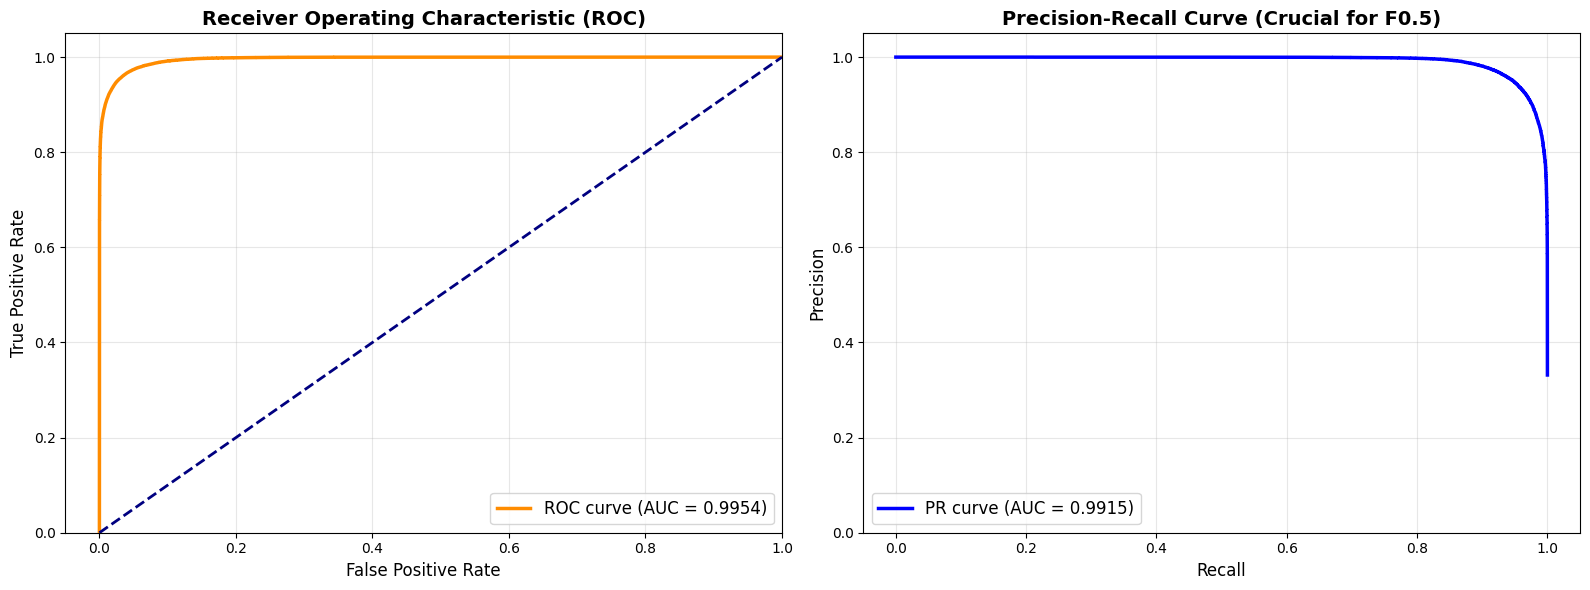


[SUMMARY] Area Under ROC Curve (AUC) : 0.9954
[SUMMARY] Area Under PR Curve (AUC)  : 0.9915


In [15]:
print("[INFO] Generating ROC and Precision-Recall Curves...")
y_true = val_preds['label'].values
y_scores = val_preds['score'].values

fpr, tpr, roc_thresholds = roc_curve(y_true, y_scores)
roc_auc = auc(fpr, tpr)
precision, recall, pr_thresholds = precision_recall_curve(y_true, y_scores)
pr_auc = auc(recall, precision)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

ax1.plot(fpr, tpr, color='darkorange', lw=2.5, label=f'ROC curve (AUC = {roc_auc:.4f})')
ax1.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
ax1.set_xlim([-0.05, 1.0])
ax1.set_ylim([0.0, 1.05])
ax1.set_xlabel('False Positive Rate', fontsize=12)
ax1.set_ylabel('True Positive Rate', fontsize=12)
ax1.set_title('Receiver Operating Characteristic (ROC)', fontsize=14, fontweight='bold')
ax1.legend(loc="lower right", fontsize=12)
ax1.grid(True, alpha=0.3)

ax2.plot(recall, precision, color='blue', lw=2.5, label=f'PR curve (AUC = {pr_auc:.4f})')
ax2.set_xlim([-0.05, 1.05])
ax2.set_ylim([0.0, 1.05])
ax2.set_xlabel('Recall', fontsize=12)
ax2.set_ylabel('Precision', fontsize=12)
ax2.set_title('Precision-Recall Curve (Crucial for F0.5)', fontsize=14, fontweight='bold')
ax2.legend(loc="lower left", fontsize=12)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "roc_pr_curves.png")
plt.show()

print(f"\n[SUMMARY] Area Under ROC Curve (AUC) : {roc_auc:.4f}")
print(f"[SUMMARY] Area Under PR Curve (AUC)  : {pr_auc:.4f}")
